<div style="background: #0d1117; border: 2px solid #30363d; padding: 36px 40px; border-radius: 16px; margin-bottom: 30px; font-family: 'Segoe UI', -apple-system, sans-serif; box-shadow: 0 20px 40px rgba(0,0,0,0.4), 0 0 0 1px rgba(255,255,255,0.05); max-width: 100%; box-sizing: border-box;">
  
  <div style="margin-bottom: 18px; display: flex; align-items: center; gap: 12px; flex-wrap: wrap;">
    <span style="background: #ff5a1f; color: #ffffff; padding: 4px 10px; border-radius: 6px; font-size: 0.72rem; font-weight: 800; text-transform: uppercase; letter-spacing: 1.5px; box-shadow: 0 2px 8px rgba(255, 90, 31, 0.4);">
      CRISIS INFORMATICS
    </span>
    <span style="color: #8b949e; font-family: monospace; font-size: 0.75rem; font-weight: 600; letter-spacing: 0.5px;">
      Kaggle Competitions &bull; NLP Pipeline v1.0
    </span>
  </div>

  <h1 style="color: #f0f6fc; margin: 0 0 8px 0; font-size: 2.4em; font-weight: 800; letter-spacing: -1px; line-height: 1.1;">
    NLP — Disaster Tweet <span style="background: linear-gradient(90deg, #ff5a1f, #ff8a00); -webkit-background-clip: text; -webkit-text-fill-color: transparent;">Classification</span>
  </h1>
  
  <p style="color: #c9d1d9; margin: 0 0 24px 0; font-size: 1.05em; font-weight: 400; line-height: 1.5; max-width: 850px;">
    Distinguishing real-time emergency signals from noise. Features custom regex tokenizers, a sparse TF-IDF vector space, and comparative ML benchmarking.
  </p>
  
  <div style="display: grid; grid-template-columns: repeat(auto-fit, minmax(160px, 1fr)); gap: 12px; background: #161b22; padding: 16px; border-radius: 10px; border: 1px solid #21262d; margin-bottom: 20px;">
    <div>
      <span style="color: #8b949e; font-size: 0.72rem; text-transform: uppercase; letter-spacing: 1px; display: block; margin-bottom: 4px;">Dataset Volume</span>
      <span style="color: #f0f6fc; font-weight: 700; font-size: 0.95rem;">7,613 Sample Tweets</span>
    </div>
    <div>
      <span style="color: #8b949e; font-size: 0.72rem; text-transform: uppercase; letter-spacing: 1px; display: block; margin-bottom: 4px;">Feature Extraction</span>
      <span style="color: #58a6ff; font-weight: 700; font-size: 0.95rem;">TF-IDF Matrix</span>
    </div>
    <div>
      <span style="color: #8b949e; font-size: 0.72rem; text-transform: uppercase; letter-spacing: 1px; display: block; margin-bottom: 4px;">Target Variables</span>
      <span style="color: #ff7b72; font-weight: 700; font-size: 0.95rem;">[1 = Real | 0 = Fake]</span>
    </div>
  </div>

  <div style="display: flex; flex-wrap: wrap; gap: 8px; align-items: center;">
    <span style="background: rgba(255,255,255,0.05); color: #c9d1d9; border: 1px solid #30363d; padding: 4px 12px; border-radius: 6px; font-size: 0.8rem; font-weight: 600;">Regex & NLTK</span>
    <span style="background: rgba(255,255,255,0.05); color: #c9d1d9; border: 1px solid #30363d; padding: 4px 12px; border-radius: 6px; font-size: 0.8rem; font-weight: 600;">Logistic Regression</span>
    <span style="background: rgba(255,255,255,0.05); color: #c9d1d9; border: 1px solid #30363d; padding: 4px 12px; border-radius: 6px; font-size: 0.8rem; font-weight: 600;">Linear SVM</span>
    <span style="background: rgba(255,255,255,0.05); color: #c9d1d9; border: 1px solid #30363d; padding: 4px 12px; border-radius: 6px; font-size: 0.8rem; font-weight: 600;">Random Forest</span>
  </div>

</div>

---

## Section 1 — Business Problem

Twitter has become one of the most important real-time communication channels during emergencies. Disaster relief organisations, news agencies, and government bodies increasingly monitor Twitter to detect crisis situations as they develop.

However, not every tweet containing words like "fire," "evacuate," or "flood" actually describes a real disaster. People routinely use disaster-related language metaphorically:

> *"The traffic on the highway is ablaze"*  
> *"My exam was a total disaster"*  
> *"This party is going to be on fire 🔥"*

**The business problem:** Build a machine learning model that can automatically classify whether a tweet describes a **genuine disaster** or not — enabling real-time monitoring systems to:
- Route true emergency alerts to crisis response teams
- Filter false positives from metaphorical or casual language
- Power early-warning dashboards for emergency management agencies
- Assist journalists in identifying breaking disaster news at scale

---

### Target Encoding

| Label | Meaning |
|---|---|
| `1` | **Real Disaster** — tweet describes an actual emergency event |
| `0` | **Not a Disaster** — metaphorical, humorous, or unrelated use of disaster language |

### Competition Context

This dataset is from the **Kaggle "NLP with Disaster Tweets"** getting-started competition. It is one of the most widely used NLP classification benchmarks for text preprocessing and feature engineering practice.

> **Competition link:** https://www.kaggle.com/competitions/nlp-getting-started


---

## Section 2 — Dataset Overview

The dataset contains 7,613 tweets hand-labelled as real disaster (1) or not (0), with additional metadata fields.

| Column | Description | Completeness |
|---|---|---|
| `id` | Unique tweet identifier | 100% |
| `keyword` | Disaster-related keyword from the tweet (URL-encoded) | 99.2% |
| `location` | User-reported location (very noisy) | 66.7% |
| `text` | Raw tweet content | 100% |
| `target` | Label — 1 = real disaster, 0 = not | 100% |

### Key Dataset Characteristics

- **Moderate class imbalance** — 57% non-disaster / 43% disaster (manageable, no heavy resampling needed)
- **Short text** — tweets are capped at 140/280 characters; average length ~101 characters
- **Noisy text** — URLs, hashtags, @mentions, special characters, abbreviations
- **Rich metadata** — keyword and location can add signal beyond raw text alone


---

## Section 3 — Import Libraries


In [4]:
import warnings
warnings.filterwarnings("ignore")

# Core
import pandas as pd
import numpy as np
import re
import string
import joblib
from collections import Counter

# NLP
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

# Download required NLTK data
nltk.download("stopwords", quiet=True)
nltk.download("punkt",     quiet=True)
nltk.download("wordnet",   quiet=True)
nltk.download("punkt_tab", quiet=True)

# Sklearn — Feature Extraction
from sklearn.feature_extraction.text import TfidfVectorizer

# Sklearn — Models
from sklearn.svm import SVC

# Sklearn — Model Selection
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    GridSearchCV,
    cross_val_score,
)

# Sklearn — Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
    roc_curve,
)

# Sklearn — Pipeline
from sklearn.pipeline import Pipeline

# Visualization
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

# ── Plotting style ────────────────────────────────────────────────────────────
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({"figure.dpi": 110, "axes.titlesize": 13, "axes.labelsize": 11})

# ── Constants ─────────────────────────────────────────────────────────────────
RANDOM_STATE = 42
MODEL_COLORS = {
    "SVM": "#58a6ff",
}

print("Libraries loaded.")


Libraries loaded.


---

## Section 4 — Load Data


In [5]:
# ── Load dataset ──────────────────────────────────────────────────────────────
df = pd.read_csv("../data/train.csv")

print(f"Dataset shape  : {df.shape[0]:,} rows  ×  {df.shape[1]} columns")
print()
print("Columns:", df.columns.tolist())
print()
print("Target distribution:")
print(df["target"].value_counts())
print()
print("Class proportions:")
print(df["target"].value_counts(normalize=True).round(3))


Dataset shape  : 7,613 rows  ×  5 columns

Columns: ['id', 'keyword', 'location', 'text', 'target']

Target distribution:
target
0    4342
1    3271
Name: count, dtype: int64

Class proportions:
target
0    0.57
1    0.43
Name: proportion, dtype: float64


In [6]:
df.head(10)


,id,keyword,location,text,target
0,1,NaN,NaN,Our Deeds are the Reason of this #earthquake M...,1
1,4,NaN,NaN,Forest fire near La Ronge Sask. Canada,1
2,5,NaN,NaN,All residents asked to 'shelter in place' are ...,1
3,6,NaN,NaN,"13,000 people receive #wildfires evacuation or...",1
4,7,NaN,NaN,Just got sent this photo from Ruby #Alaska as ...,1
5,8,NaN,NaN,#RockyFire Update => California Hwy. 20 closed...,1
6,10,NaN,NaN,#flood #disaster Heavy rain causes flash flood...,1
7,13,NaN,NaN,I'm on top of the hill and I can see a fire in...,1
8,14,NaN,NaN,There's an emergency evacuation happening now ...,1
9,15,NaN,NaN,I'm afraid that the tornado is coming to our a...,1


In [7]:
# ── Missing value profile ─────────────────────────────────────────────────────
missing = df.isnull().sum()
pct = (missing / len(df) * 100).round(2)
print(pd.DataFrame({"Missing": missing, "Missing %": pct})
      .sort_values("Missing", ascending=False))
print()
print("Note:")
print("  keyword  — 61 missing (0.8%)  → fill with 'unknown'")
print("  location — 2,533 missing (33%) → high noise, used as optional feature")
print("  text     — 0 missing  → complete")


          Missing  Missing %
location     2533      33.27
keyword        61       0.80
id              0       0.00
text            0       0.00
target          0       0.00

Note:
  keyword  — 61 missing (0.8%)  → fill with 'unknown'
  location — 2,533 missing (33%) → high noise, used as optional feature
  text     — 0 missing  → complete


---

## Section 5 — Data Understanding


In [8]:
# ── Text length and word count statistics ─────────────────────────────────────
df["text_length"]  = df["text"].str.len()
df["word_count"]   = df["text"].str.split().str.len()
df["char_count"]   = df["text"].str.replace(" ", "").str.len()
df["has_url"]      = df["text"].str.contains(r"http", case=False, regex=True).astype(int)
df["has_hashtag"]  = df["text"].str.contains(r"#").astype(int)
df["has_mention"]  = df["text"].str.contains(r"@").astype(int)
df["excl_count"]   = df["text"].str.count(r"!")
df["question_count"] = df["text"].str.count(r"\?")
df["uppercase_ratio"] = df["text"].apply(
    lambda x: sum(1 for c in str(x) if c.isupper()) / max(len(str(x)), 1)
)

print("Text Feature Statistics:")
print(df[["text_length","word_count","has_url","has_hashtag","has_mention",
          "uppercase_ratio"]].describe().round(3))


Text Feature Statistics:
       text_length  word_count   has_url  has_hashtag  has_mention  \
count     7613.000    7613.000  7613.000     7613.000     7613.000   
mean       101.037      14.904     0.522        0.231        0.268   
std         33.781       5.733     0.500        0.422        0.443   
min          7.000       1.000     0.000        0.000        0.000   
25%         78.000      11.000     0.000        0.000        0.000   
50%        107.000      15.000     1.000        0.000        0.000   
75%        133.000      19.000     1.000        0.000        1.000   
max        157.000      31.000     1.000        1.000        1.000   

       uppercase_ratio  
count         7613.000  
mean             0.100  
std              0.107  
min              0.000  
25%              0.038  
50%              0.075  
75%              0.126  
max              1.000  


In [9]:
# ── Feature comparison by target class ───────────────────────────────────────
print("Feature Means by Target Class:")
compare_cols = ["text_length","word_count","has_url","has_hashtag",
                "has_mention","uppercase_ratio","excl_count"]
print(df.groupby("target")[compare_cols].mean().round(3).T.to_string())


Feature Means by Target Class:
target                0        1
text_length      95.707  108.113
word_count       14.705   15.168
has_url           0.414    0.664
has_hashtag       0.204    0.268
has_mention       0.314    0.207
uppercase_ratio   0.098    0.102
excl_count        0.194    0.101


In [10]:
# ── Sample tweets ─────────────────────────────────────────────────────────────
print("=" * 70)
print("REAL DISASTER tweets (target=1):")
print("=" * 70)
for txt in df[df["target"]==1]["text"].sample(5, random_state=42).values:
    print(f"  • {txt[:120]}")

print()
print("=" * 70)
print("NOT DISASTER tweets (target=0):")
print("=" * 70)
for txt in df[df["target"]==0]["text"].sample(5, random_state=42).values:
    print(f"  • {txt[:120]}")


REAL DISASTER tweets (target=1):
  • Nearly 50 thousand people affected by floods in #Paraguay ? http://t.co/aw23wXtyjB http://t.co/ABgct9VFUa
  • Vladimir Putin Issues Major Warning But Is It Too Late To Escape Armageddon?
http://t.co/gBxafy1m1C
  • @DoctorFluxx @StefanEJones @spinnellii @themermacorn  No burning buildings and rob during a riot. That's embarrassing &a
  • Telnet attacked from 124.13.172.40 (STREAMYX-HOME-SOUTHERN MY)
  • LONDON IS DROWNING AND IIII LIVE BY THE RIVEEEEEER

NOT DISASTER tweets (target=0):
  • Everyday is a near death fatality for me on the road. Thank god is on my side.??
  • #Lifestyle Û÷It makes me sickÛª: Baby clothes deemed a Û÷hazardÛª http://t.co/0XrfVidxA2 http://t.co/oIHwgEZDCk
  • @Lenn_Len Probably. We are inundated with them most years!
  • A demoness with the voice of an angel. Like a siren's call beckoning me to the void. Don't ?? on thisÛ_ https://t.co/nP
  • Next Man Up---AH SCREW THIS! I'm so tired of injuries.  

What happened to C

---

## Section 6 — Exploratory Data Analysis

EDA explores the linguistic and structural differences between real disaster tweets and non-disaster tweets.


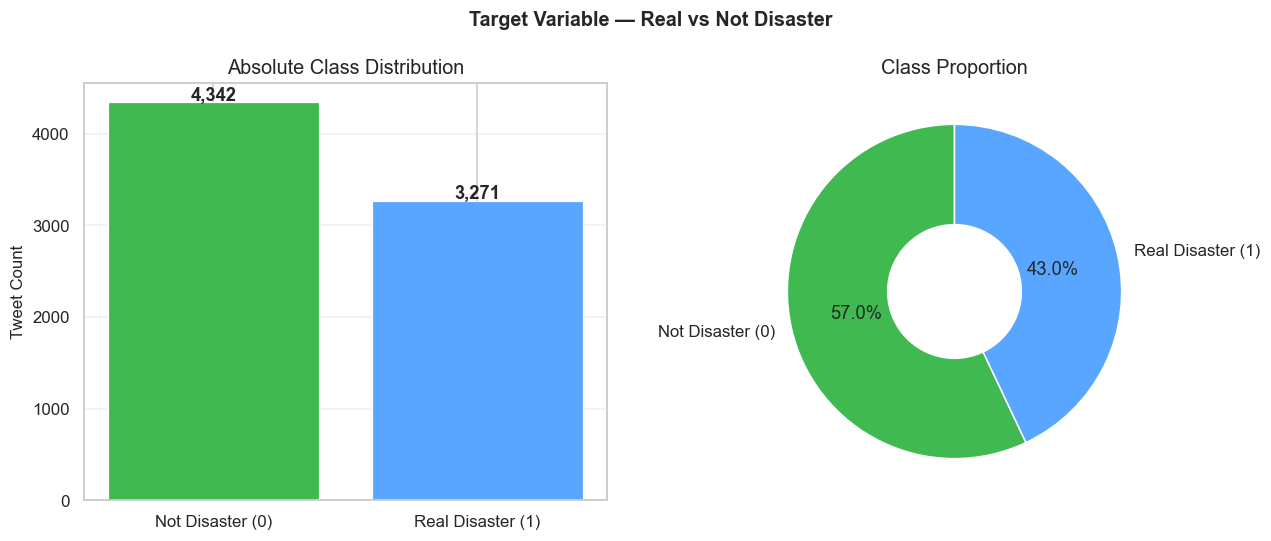

In [11]:
# ── 6.1 Target distribution ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

counts = df["target"].value_counts()
colors = ["#3fb950", "#58a6ff"]

axes[0].bar(["Not Disaster (0)", "Real Disaster (1)"], counts.values,
            color=colors, edgecolor="white", linewidth=0.8)
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 20, f"{v:,}", ha="center", fontweight="bold")
axes[0].set_title("Absolute Class Distribution")
axes[0].set_ylabel("Tweet Count")
axes[0].grid(True, alpha=0.3, axis="y")

axes[1].pie(counts.values, labels=["Not Disaster (0)", "Real Disaster (1)"],
            colors=colors, autopct="%1.1f%%", startangle=90,
            wedgeprops=dict(width=0.6))
axes[1].set_title("Class Proportion")

plt.suptitle("Target Variable — Real vs Not Disaster", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("../outputs/eda/target_distribution.png", bbox_inches="tight")
plt.show()


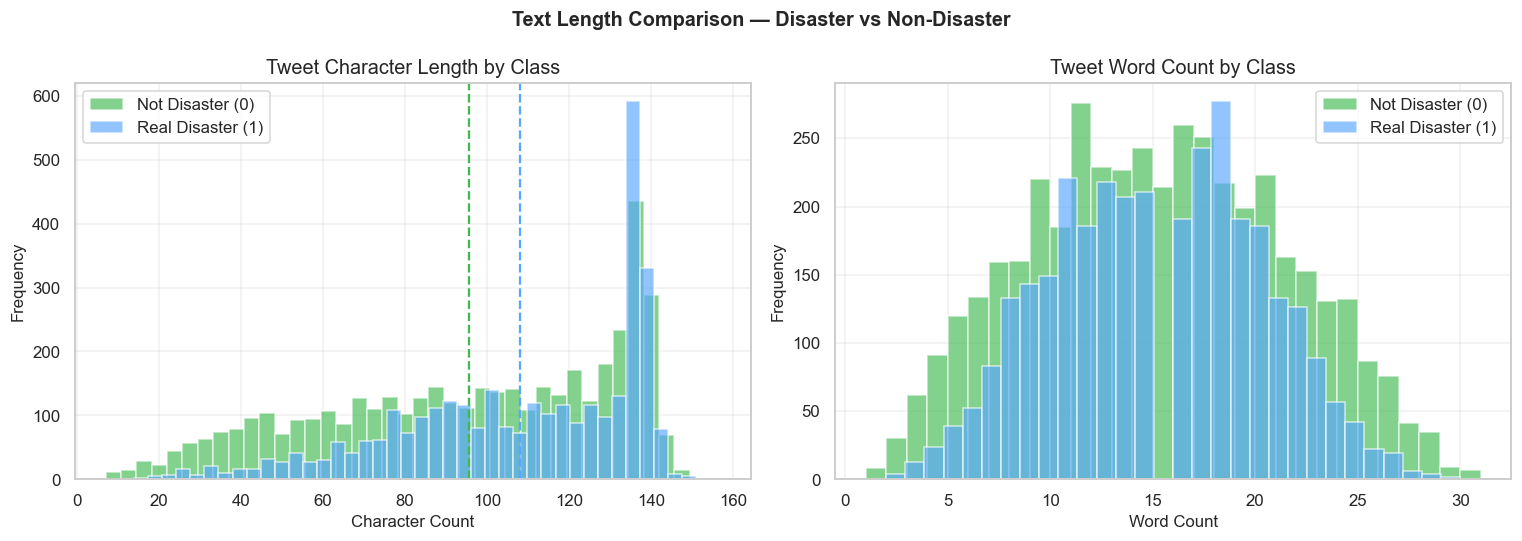

In [12]:
# ── 6.2 Text length distributions ────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for target_val, label, color in [
    (0, "Not Disaster (0)", "#3fb950"),
    (1, "Real Disaster (1)", "#58a6ff"),
]:
    data = df[df["target"] == target_val]
    axes[0].hist(data["text_length"], bins=40, alpha=0.65, color=color, label=label)
    axes[1].hist(data["word_count"],  bins=30, alpha=0.65, color=color, label=label)

axes[0].set_title("Tweet Character Length by Class")
axes[0].set_xlabel("Character Count")
axes[0].set_ylabel("Frequency")
axes[0].legend(); axes[0].grid(True, alpha=0.3)
axes[0].axvline(df[df["target"]==0]["text_length"].mean(),
                color="#3fb950", linestyle="--", linewidth=1.5,
                label=f"Mean (0): {df[df['target']==0]['text_length'].mean():.0f}")
axes[0].axvline(df[df["target"]==1]["text_length"].mean(),
                color="#58a6ff", linestyle="--", linewidth=1.5,
                label=f"Mean (1): {df[df['target']==1]['text_length'].mean():.0f}")

axes[1].set_title("Tweet Word Count by Class")
axes[1].set_xlabel("Word Count")
axes[1].set_ylabel("Frequency")
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.suptitle("Text Length Comparison — Disaster vs Non-Disaster", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("../outputs/eda/text_length_distribution.png", bbox_inches="tight")
plt.show()


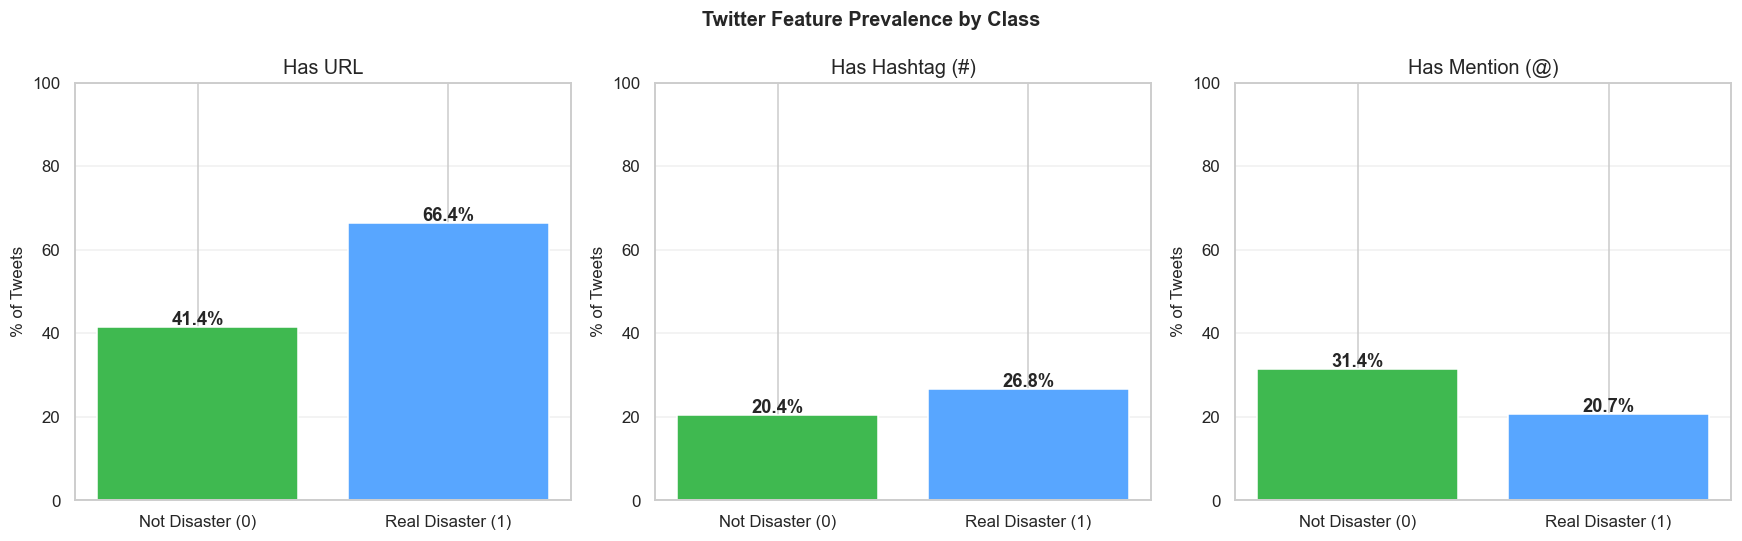

In [13]:
# ── 6.3 URL / hashtag / mention presence ─────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, col, title in zip(
    axes,
    ["has_url", "has_hashtag", "has_mention"],
    ["Has URL", "Has Hashtag (#)", "Has Mention (@)"],
):
    means = df.groupby("target")[col].mean() * 100
    bars = ax.bar(["Not Disaster (0)", "Real Disaster (1)"],
                  means.values, color=colors, edgecolor="white")
    for bar, val in zip(bars, means.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f"{val:.1f}%", ha="center", fontweight="bold")
    ax.set_title(title)
    ax.set_ylabel("% of Tweets")
    ax.set_ylim(0, 100)
    ax.grid(True, alpha=0.3, axis="y")

plt.suptitle("Twitter Feature Prevalence by Class", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("../outputs/eda/twitter_features.png", bbox_inches="tight")
plt.show()


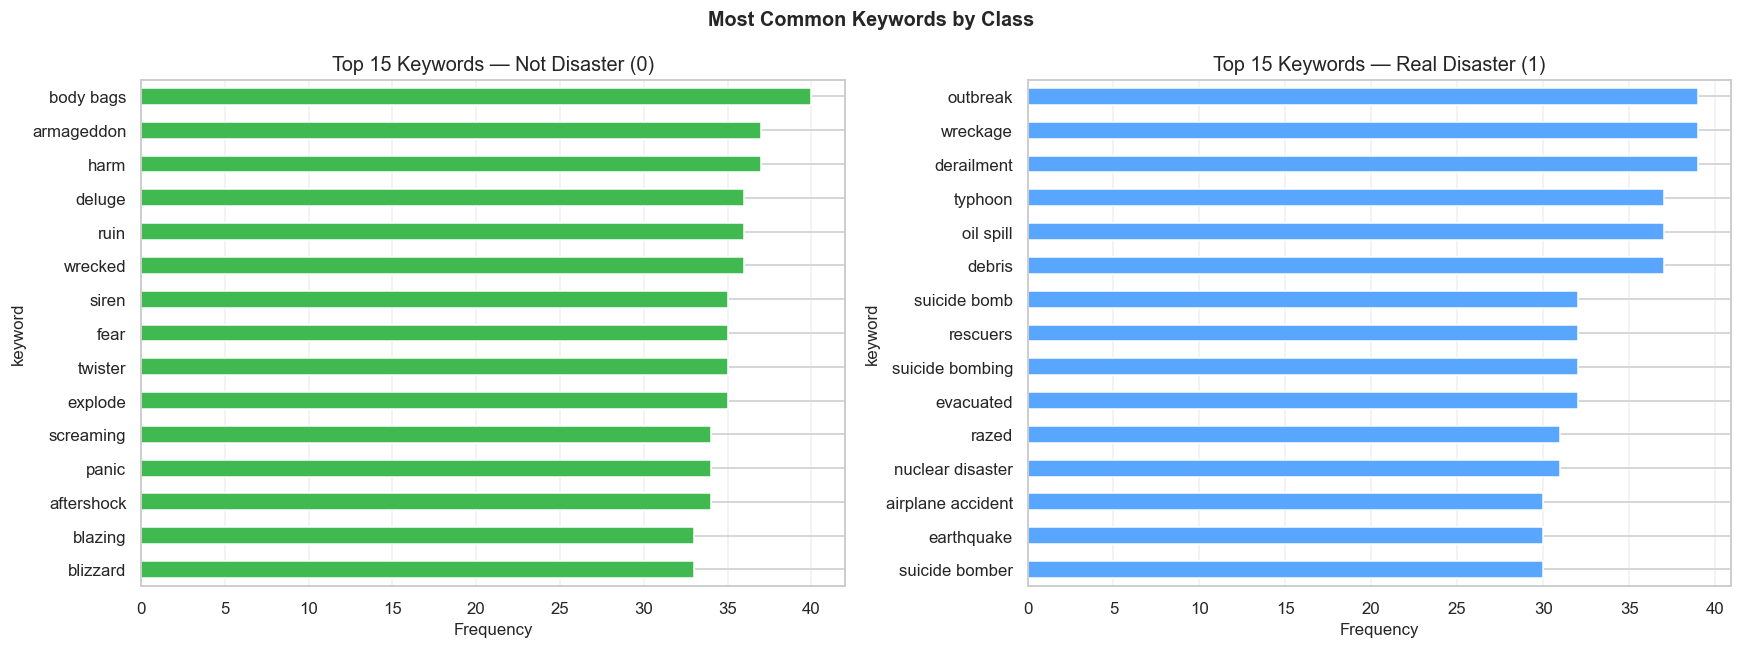

In [14]:
# ── 6.4 Top keywords by class ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, target_val, label, color in [
    (axes[0], 0, "Not Disaster (0)", "#3fb950"),
    (axes[1], 1, "Real Disaster (1)", "#58a6ff"),
]:
    kw = (
        df[df["target"] == target_val]["keyword"]
        .dropna()
        .str.replace("%20", " ")
        .value_counts()
        .head(15)
        .sort_values()
    )
    kw.plot(kind="barh", ax=ax, color=color, edgecolor="white")
    ax.set_title(f"Top 15 Keywords — {label}")
    ax.set_xlabel("Frequency")
    ax.grid(True, alpha=0.3, axis="x")

plt.suptitle("Most Common Keywords by Class", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("../outputs/eda/top_keywords.png", bbox_inches="tight")
plt.show()


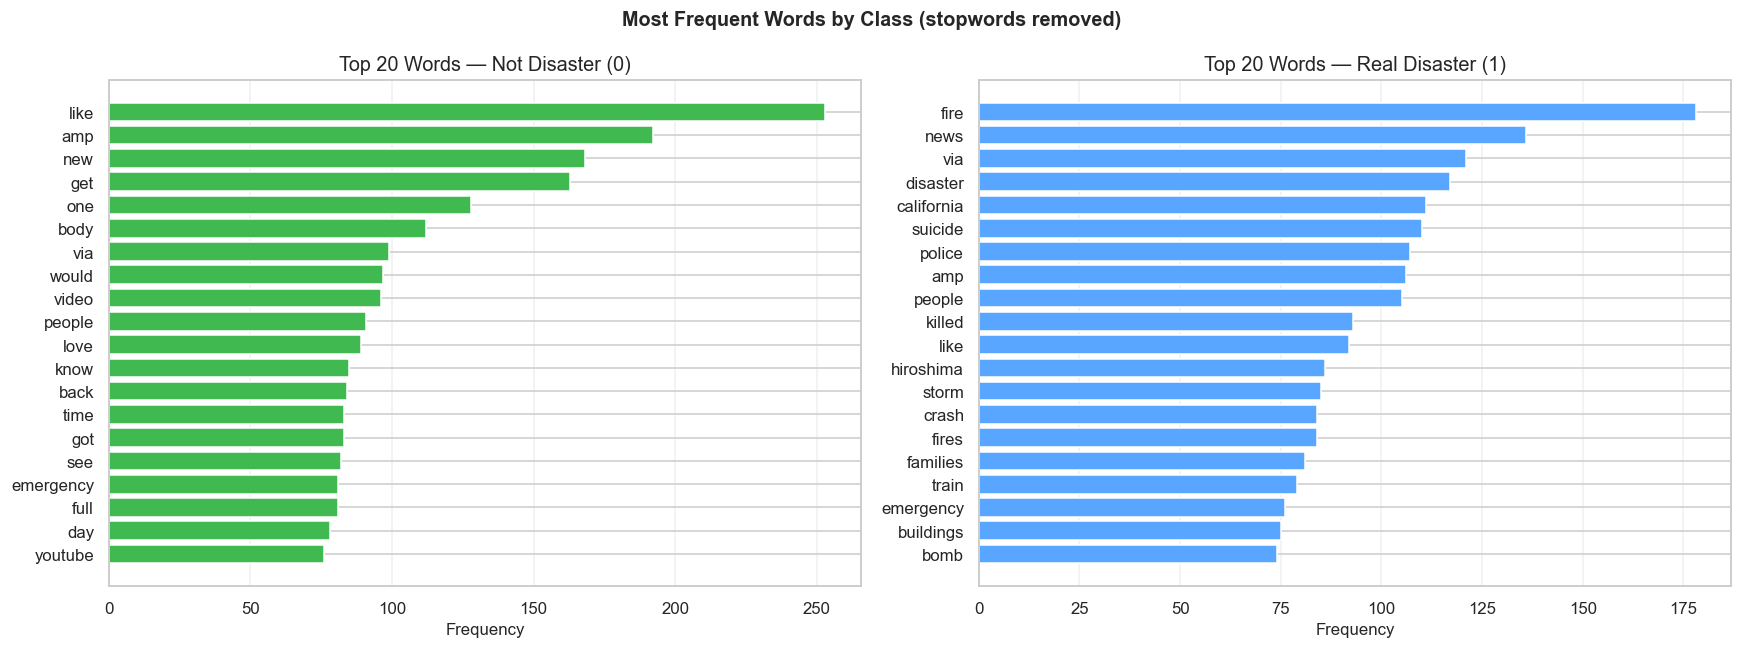

In [15]:
# ── 6.5 Most common words per class (raw) ────────────────────────────────────
from collections import Counter

stop_words_set = set(stopwords.words("english"))

def get_top_words(texts, n=20):
    all_words = []
    for text in texts:
        words = str(text).lower().split()
        words = [w.strip(string.punctuation) for w in words
                 if w.strip(string.punctuation) not in stop_words_set
                 and len(w.strip(string.punctuation)) > 2]
        all_words.extend(words)
    return Counter(all_words).most_common(n)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, target_val, label, color in [
    (axes[0], 0, "Not Disaster (0)", "#3fb950"),
    (axes[1], 1, "Real Disaster (1)", "#58a6ff"),
]:
    top_words = get_top_words(df[df["target"] == target_val]["text"])
    words, counts = zip(*top_words)
    ax.barh(list(words), list(counts), color=color, edgecolor="white")
    ax.set_title(f"Top 20 Words — {label}")
    ax.set_xlabel("Frequency")
    ax.invert_yaxis()
    ax.grid(True, alpha=0.3, axis="x")

plt.suptitle("Most Frequent Words by Class (stopwords removed)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("../outputs/eda/top_words.png", bbox_inches="tight")
plt.show()


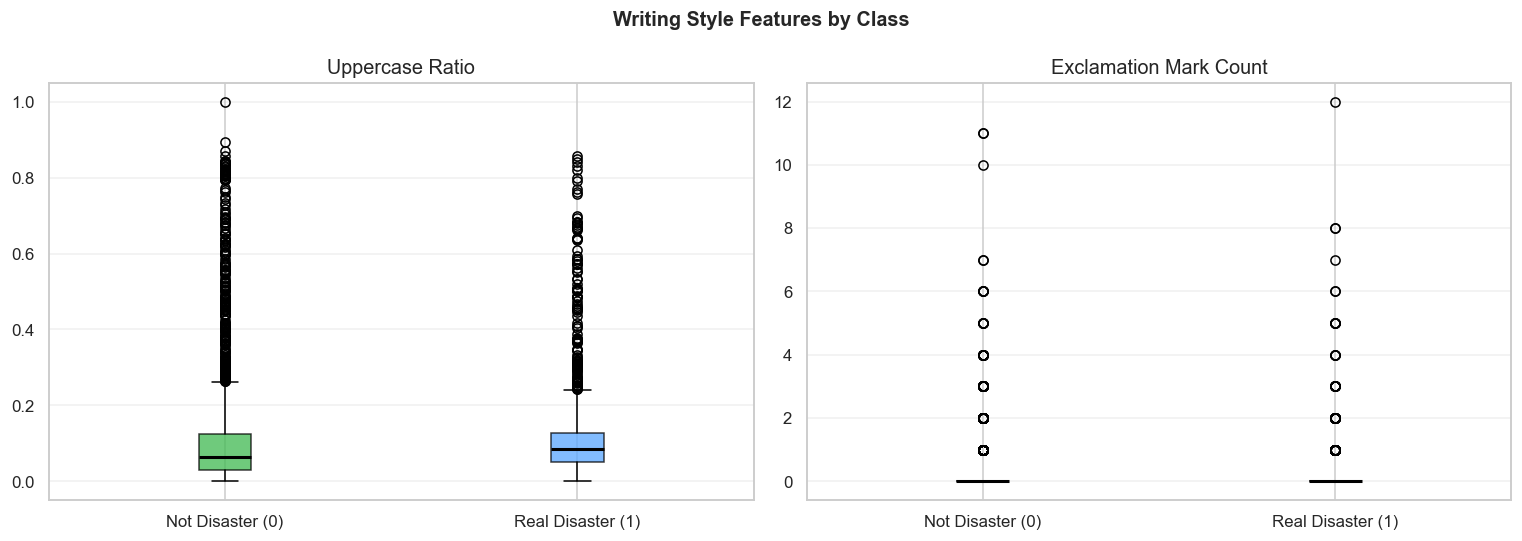

In [16]:
# ── 6.6 Uppercase ratio and punctuation ──────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, col, title in zip(
    axes,
    ["uppercase_ratio", "excl_count"],
    ["Uppercase Ratio", "Exclamation Mark Count"],
):
    bp = ax.boxplot(
        [df[df["target"]==0][col].values,
         df[df["target"]==1][col].values],
        patch_artist=True,
        medianprops=dict(color="black", linewidth=2),
    )
    for patch, color in zip(bp["boxes"], colors):
        patch.set_facecolor(color); patch.set_alpha(0.75)
    ax.set_xticklabels(["Not Disaster (0)", "Real Disaster (1)"])
    ax.set_title(title)
    ax.grid(True, alpha=0.3, axis="y")

plt.suptitle("Writing Style Features by Class", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("../outputs/eda/writing_style.png", bbox_inches="tight")
plt.show()


---

## Section 7 — Text Preprocessing

Raw tweets contain significant noise that degrades NLP model performance. A systematic preprocessing pipeline is applied to clean and normalize the text.

### Preprocessing Steps

| Step | Reason |
|---|---|
| **Lowercase** | Normalizes word forms — "Fire" and "fire" are the same word |
| **Remove URLs** | URLs are unique per tweet and carry no semantic signal |
| **Remove @mentions** | Username references add no topical content |
| **Remove #hashtag symbols** | Keep the word, remove the `#` — "wildfire" is informative, `#` is not |
| **Remove numbers** | Standalone numbers add minimal NLP signal |
| **Remove punctuation** | Punctuation noise without semantic benefit |
| **Remove extra whitespace** | Normalization artifact |
| **Tokenization** | Split text into individual word tokens |
| **Stopword removal** | Remove high-frequency, low-information words (the, is, at, ...) |
| **Lemmatization** | Reduce inflected forms to base form — "fires/fired/firing" → "fire" |

> **Why lemmatization over stemming?** Lemmatization produces real dictionary words (better for TF-IDF interpretability). Stemming can produce non-words like "fir" for "fires."


In [17]:
# ── Initialize NLP tools ──────────────────────────────────────────────────────
lemmatizer   = WordNetLemmatizer()
stop_words   = set(stopwords.words("english"))

def preprocess_text(text):
    """
    Full NLP preprocessing pipeline for tweet text.
    Returns cleaned, lemmatized string.
    """
    text = str(text).lower()

    # Remove URLs
    text = re.sub(r"http\S+|www\S+|https\S+", "", text)

    # Remove @mentions
    text = re.sub(r"@\w+", "", text)

    # Remove hashtag symbol but keep word
    text = re.sub(r"#(\w+)", r"", text)

    # Remove numbers
    text = re.sub(r"\d+", "", text)

    # Remove punctuation
    text = text.translate(str.maketrans("", "", string.punctuation))

    # Remove extra whitespace
    text = re.sub(r"\s+", " ", text).strip()

    # Tokenize
    tokens = word_tokenize(text)

    # Remove stopwords and short tokens
    tokens = [t for t in tokens if t not in stop_words and len(t) > 2]

    # Lemmatize
    tokens = [lemmatizer.lemmatize(t) for t in tokens]

    return " ".join(tokens)

# Apply preprocessing
df["clean_text"] = df["text"].apply(preprocess_text)

print("Sample preprocessing results:")
print()
for i in range(5):
    print(f"Original : {df['text'].iloc[i][:100]}")
    print(f"Cleaned  : {df['clean_text'].iloc[i][:100]}")
    print()


Sample preprocessing results:

Original : Our Deeds are the Reason of this #earthquake May ALLAH Forgive us all
Cleaned  : deed reason may allah forgive

Original : Forest fire near La Ronge Sask. Canada
Cleaned  : forest fire near ronge sask canada

Original : All residents asked to 'shelter in place' are being notified by officers. No other evacuation or she
Cleaned  : resident asked shelter place notified officer evacuation shelter place order expected

Original : 13,000 people receive #wildfires evacuation orders in California 
Cleaned  : people receive evacuation order california

Original : Just got sent this photo from Ruby #Alaska as smoke from #wildfires pours into a school 
Cleaned  : got sent photo ruby smoke pours school



In [18]:
# ── Verify preprocessing ──────────────────────────────────────────────────────
df["clean_length"] = df["clean_text"].str.len()
df["clean_words"]  = df["clean_text"].str.split().str.len()

print("Token count comparison (before vs after preprocessing):")
print(f"  Avg words before : {df['word_count'].mean():.1f}")
print(f"  Avg words after  : {df['clean_words'].mean():.1f}")
print(f"  Avg reduction    : {(1 - df['clean_words'].mean()/df['word_count'].mean())*100:.1f}%")
print()
print("Empty texts after cleaning (edge cases):", (df["clean_text"].str.strip() == "").sum())


Token count comparison (before vs after preprocessing):
  Avg words before : 14.9
  Avg words after  : 8.0
  Avg reduction    : 46.0%

Empty texts after cleaning (edge cases): 4


---

## Section 8 — Feature Engineering

Two types of features are engineered:

1. **TF-IDF features** — the primary representation of tweet content
2. **Meta-features** — structural tweet properties (URL presence, hashtag count, text length, etc.)

### TF-IDF Configuration

| Parameter | Value | Reason |
|---|---|---|
| `ngram_range=(1,2)` | Unigrams + bigrams | Captures phrases like "wildfires evacuation" or "forest fire" that carry more signal than single words |
| `max_df=0.95` | Ignore top 5% most common | Removes corpus-wide high-frequency terms that appear in both classes equally |
| `min_df=2` | Minimum 2 documents | Removes extremely rare terms that are likely noise or typos |
| `max_features=10000` | Vocabulary cap | Controls dimensionality and prevents overfitting on rare words |
| `sublinear_tf=True` | Log-scale term frequency | Prevents very frequent terms from dominating; 1+log(tf) instead of raw tf |
| `stop_words="english"` | Remove stopwords | Applied at vectorizer level as a secondary filter |


In [19]:
# ── Meta-features ─────────────────────────────────────────────────────────────
# These are structural tweet features beyond the text content
meta_features = df[["text_length","word_count","has_url","has_hashtag",
                     "has_mention","excl_count","question_count","uppercase_ratio"]].copy()

print(f"Meta-features shape : {meta_features.shape}")
print("Meta-features:", meta_features.columns.tolist())


Meta-features shape : (7613, 8)
Meta-features: ['text_length', 'word_count', 'has_url', 'has_hashtag', 'has_mention', 'excl_count', 'question_count', 'uppercase_ratio']


In [20]:
# ── TF-IDF Vectorizer ─────────────────────────────────────────────────────────
tfidf = TfidfVectorizer(
    ngram_range  = (1, 2),       # Unigrams + bigrams
    max_df       = 0.95,         # Ignore terms in >95% of documents
    min_df       = 2,            # Ignore terms appearing in <2 documents
    max_features = 10_000,       # Vocabulary size cap
    sublinear_tf = True,         # Log-scale TF
    stop_words   = "english",    # Secondary stopword filter
)

print("TF-IDF Vectorizer configured.")
print(f"Max features  : 10,000")
print(f"N-gram range  : (1, 2) — unigrams + bigrams")
print(f"sublinear_tf  : True — log-scale term frequency")


TF-IDF Vectorizer configured.
Max features  : 10,000
N-gram range  : (1, 2) — unigrams + bigrams
sublinear_tf  : True — log-scale term frequency


---

## Section 9 — Train-Test Split

A stratified 80/20 split ensures both train and test sets preserve the original class ratio (57%/43%).


In [21]:
# ── Features and target ───────────────────────────────────────────────────────
X_text = df["clean_text"]
y      = df["target"]

# ── Stratified split ─────────────────────────────────────────────────────────
X_train_text, X_test_text, y_train, y_test = train_test_split(
    X_text, y,
    test_size = 0.20,
    stratify  = y,
    random_state = RANDOM_STATE,
)

print(f"Train : {len(X_train_text):,} tweets  |  Disaster rate: {y_train.mean()*100:.1f}%")
print(f"Test  : {len(X_test_text):,} tweets   |  Disaster rate: {y_test.mean()*100:.1f}%")


Train : 6,090 tweets  |  Disaster rate: 43.0%
Test  : 1,523 tweets   |  Disaster rate: 42.9%


In [22]:
# ── TF-IDF transformation ─────────────────────────────────────────────────────
# Fit ONLY on training data — transform both train and test
X_train_tfidf = tfidf.fit_transform(X_train_text)
X_test_tfidf  = tfidf.transform(X_test_text)

print(f"Train TF-IDF matrix : {X_train_tfidf.shape}")
print(f"Test  TF-IDF matrix : {X_test_tfidf.shape}")
print()
print(f"Vocabulary size     : {len(tfidf.vocabulary_):,} terms")
print(f"Matrix sparsity     : {(1 - X_train_tfidf.nnz / (X_train_tfidf.shape[0] * X_train_tfidf.shape[1]))*100:.1f}%")


Train TF-IDF matrix : (6090, 7618)
Test  TF-IDF matrix : (1523, 7618)

Vocabulary size     : 7,618 terms
Matrix sparsity     : 99.9%


In [24]:
# ── Top TF-IDF terms per class ────────────────────────────────────────────────
feature_names = np.array(tfidf.get_feature_names_out())

# Get mean TF-IDF score per class
train_idx = X_train_text.index
y_train_arr = y_train.values

for target_val, label in [(0, "Not Disaster"), (1, "Real Disaster")]:
    mask = y_train_arr == target_val
    mean_tfidf = X_train_tfidf[mask].mean(axis=0).A1
    top_idx = mean_tfidf.argsort()[-15:][::-1]
    print(f"Top 15 TF-IDF terms — {label} (target={target_val}):")
    for i, idx in enumerate(top_idx):
        print(f"  {i+1:2d}. {feature_names[idx]:<25} {mean_tfidf[idx]:.4f}")


Top 15 TF-IDF terms — Not Disaster (target=0):
   1. like                      0.0131
   2. new                       0.0086
   3. amp                       0.0085
   4. dont                      0.0083
   5. love                      0.0074
   6. got                       0.0064
   7. day                       0.0063
   8. body                      0.0063
   9. time                      0.0061
  10. let                       0.0060
  11. want                      0.0058
  12. know                      0.0055
  13. going                     0.0053
  14. think                     0.0052
  15. need                      0.0052
Top 15 TF-IDF terms — Real Disaster (target=1):
   1. building                  0.0080
   2. california                0.0079
   3. storm                     0.0072
   4. suicide                   0.0070
   5. police                    0.0070
   6. disaster                  0.0068
   7. year                      0.0068
   8. people                    0.0067
   9. li

---

## Section 10 — Cross-Validation Setup

5-fold stratified cross-validation is used for all model evaluations. Stratified folds preserve the disaster/non-disaster ratio in each fold.

**Primary metric:** F1-score — balances precision and recall, appropriate for slight class imbalance  
**Secondary:** ROC-AUC — measures discriminative ability across all thresholds


In [ ]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

print("Cross-validation strategy: StratifiedKFold")
print(f"  n_splits     : 5")
print(f"  shuffle      : True")
print(f"  random_state : {RANDOM_STATE}")
print()
print("Primary scoring  : f1")
print("Secondary scoring: roc_auc")


---

## Section 11 — Model 1: Support Vector Machine (SVM)

SVM with a **linear kernel** is one of the strongest classical NLP classifiers. It finds the maximum-margin hyperplane in the TF-IDF feature space, which works exceptionally well for high-dimensional sparse text data.

**Why SVM for text?**
- High-dimensional sparse features (10,000 TF-IDF dimensions) are where linear SVM excels
- Margin-based learning is robust to the curse of dimensionality
- `probability=True` enables probability calibration for ROC-AUC evaluation

**Tuning:** `C` (regularization strength) via `GridSearchCV`


In [ ]:
# ── SVM Pipeline ─────────────────────────────────────────────────────────────
svm_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(
        ngram_range=  (1, 2),
        max_df       = 0.95,
        min_df       = 2,
        max_features = 10_000,
        sublinear_tf = True,
        stop_words   = "english",
    )),
    ("model", SVC(
        kernel      = "linear",
        probability = True,
        random_state= RANDOM_STATE,
    )),
])

param_grid_svm = {
    "model__C": [0.01, 0.1, 1, 10],
}

svm_search = GridSearchCV(
    svm_pipeline, param_grid_svm,
    scoring="f1", cv=cv, n_jobs=-1, verbose=0,
)

print("Training SVM with GridSearchCV...")
svm_search.fit(X_train_text, y_train)

print(f"Best C     : {svm_search.best_params_['model__C']}")
print(f"Best CV F1 : {svm_search.best_score_:.4f}")
best_svm = svm_search.best_estimator_


In [ ]:
# ── SVM evaluation ────────────────────────────────────────────────────────────
y_prob_svm = best_svm.predict_proba(X_test_text)[:, 1]
y_pred_svm = best_svm.predict(X_test_text)

svm_metrics = {
    "Accuracy" : accuracy_score(y_test, y_pred_svm),
    "Precision": precision_score(y_test, y_pred_svm, zero_division=0),
    "Recall"   : recall_score(y_test, y_pred_svm, zero_division=0),
    "F1"       : f1_score(y_test, y_pred_svm, zero_division=0),
    "ROC-AUC"  : roc_auc_score(y_test, y_prob_svm),
    "PR-AUC"   : average_precision_score(y_test, y_prob_svm),
}

print("=" * 50)
print("SVM — RESULTS")
print("=" * 50)
for k, v in svm_metrics.items():
    print(f"  {k:<12}: {v:.4f}")
print()
print("Classification Report:")
print(classification_report(y_test, y_pred_svm,
      target_names=["Not Disaster (0)", "Real Disaster (1)"]))


In [ ]:
# ── SVM confusion matrix + ROC ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm_svm = confusion_matrix(y_test, y_pred_svm)
sns.heatmap(cm_svm, annot=True, fmt="d", cmap="Blues", ax=axes[0],
            xticklabels=["Pred: Not Disaster","Pred: Real Disaster"],
            yticklabels=["Actual: Not Disaster","Actual: Real Disaster"],
            annot_kws={"size": 14, "weight": "bold"})
axes[0].set_title("SVM — Confusion Matrix")

fpr_svm, tpr_svm, _ = roc_curve(y_test, y_prob_svm)
roc_svm = roc_auc_score(y_test, y_prob_svm)
axes[1].plot(fpr_svm, tpr_svm, color="#58a6ff", linewidth=2.5,
             label=f"SVM  (AUC = {roc_svm:.4f})")
axes[1].plot([0,1],[0,1], "--", color="#6e7681", linewidth=1)
axes[1].set_title("SVM — ROC Curve")
axes[1].set_xlabel("False Positive Rate"); axes[1].set_ylabel("True Positive Rate")
axes[1].legend(); axes[1].grid(True, alpha=0.4)

plt.tight_layout()
plt.savefig("../outputs/svm_results.png", bbox_inches="tight")
plt.show()


In [ ]:
# ── Comparison table ──────────────────────────────────────────────────────────
comparison_df = pd.DataFrame({
    "Model"    : ["SVM", "Logistic Regression", "Random Forest"],
    "Accuracy" : [svm_metrics["Accuracy"],  lr_metrics["Accuracy"],  rf_metrics["Accuracy"]],
    "Precision": [svm_metrics["Precision"], lr_metrics["Precision"], rf_metrics["Precision"]],
    "Recall"   : [svm_metrics["Recall"],    lr_metrics["Recall"],    rf_metrics["Recall"]],
    "F1"       : [svm_metrics["F1"],        lr_metrics["F1"],        rf_metrics["F1"]],
    "ROC-AUC"  : [svm_metrics["ROC-AUC"],   lr_metrics["ROC-AUC"],   rf_metrics["ROC-AUC"]],
    "PR-AUC"   : [svm_metrics["PR-AUC"],    lr_metrics["PR-AUC"],    rf_metrics["PR-AUC"]],
})

print("Model Comparison Summary:")
print(comparison_df.set_index("Model").round(4).to_string())
print()
best_model_name = comparison_df.loc[comparison_df["F1"].idxmax(), "Model"]
best_f1         = comparison_df["F1"].max()
print(f"Best model by F1 : {best_model_name}  (F1 = {best_f1:.4f})")


In [ ]:
# ── Combined confusion matrices ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

cmaps  = ["Blues", "Greens", "Oranges"]
models = [
    ("SVM",                 confusion_matrix(y_test, y_pred_svm)),
    ("Logistic Regression", confusion_matrix(y_test, y_pred_lr)),
    ("Random Forest",       confusion_matrix(y_test, y_pred_rf)),
]

for ax, cmap, (name, cm) in zip(axes, cmaps, models):
    sns.heatmap(cm, annot=True, fmt="d", cmap=cmap, ax=ax,
                xticklabels=["Pred: Not Dis.", "Pred: Real Dis."],
                yticklabels=["Actual: Not Dis.", "Actual: Real Dis."],
                annot_kws={"size": 13, "weight": "bold"})
    ax.set_title(name)

plt.suptitle("Confusion Matrices — All Models", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("../outputs/all_confusion_matrices.png", bbox_inches="tight")
plt.show()


---

## Section 15 — Precision-Recall Analysis

For the disaster detection use case, **Recall is critical** — missing a real disaster (False Negative) has higher business cost than a false alert (False Positive). The PR curve shows the precision-recall tradeoff at different thresholds for the best model.


---

## Section 16 — Live Prediction Demo

The best model is used to classify new unseen tweets — demonstrating the end-to-end pipeline in action.


In [ ]:
# ── Predict on new tweets ─────────────────────────────────────────────────────
sample_tweets = [
    # Likely real disasters
    "Massive earthquake hits coastal city, buildings collapse and thousands evacuated",
    "Wildfires spreading rapidly across California, residents ordered to evacuate immediately",
    "Flash flood warning issued for downtown area, roads impassable",
    "Breaking: Bridge collapses over river, multiple vehicles plunged into water",
    # Likely not disasters
    "This exam was an absolute disaster, I totally bombed it",
    "Our team was on fire last night, absolutely crushed it in the final quarter",
    "Can we meet for lunch tomorrow? The traffic here is killing me",
    "My computer crashed again — this is a complete catastrophe",
]

# Preprocess samples
sample_clean = [preprocess_text(t) for t in sample_tweets]

# Predict
sample_preds  = production_model.predict(sample_clean)
sample_probs  = production_model.predict_proba(sample_clean)[:, 1]

print(f"{'Prediction':<18} {'Probability':>12}   Tweet")
print("─" * 90)
for tweet, pred, prob in zip(sample_tweets, sample_preds, sample_probs):
    label = "🔴 REAL DISASTER" if pred == 1 else "🟢 NOT DISASTER "
    print(f"{label}   {prob:>10.4f}   {tweet[:70]}")


<div style="background: #0d1117; border: 2px solid #30363d; border-left: 6px solid #ff5a1f; padding: 28px 32px; border-radius: 12px; margin: 24px 0; font-family: 'Segoe UI', -apple-system, sans-serif; box-shadow: 0 16px 32px rgba(0,0,0,0.3); max-width: 100%; box-sizing: border-box;">

<div style="border-bottom: 1px dashed #30363d; padding-bottom: 14px; margin-bottom: 20px;">
<span style="color: #8b949e; font-family: monospace; font-size: 0.75rem; font-weight: 700; letter-spacing: 1px; text-transform: uppercase; display: block; margin-bottom: 4px;">SYSTEM LOG // ANALYSIS</span>
<h2 style="color: #f0f6fc; margin: 0; font-size: 1.6em; font-weight: 800; letter-spacing: -0.5px;">Section 17 — NLP Insights & <span style="background: linear-gradient(90deg, #ff5a1f, #ff8a00); -webkit-background-clip: text; -webkit-text-fill-color: transparent;">Key Findings</span></h2>
</div>

<div style="display: flex; flex-direction: column; gap: 20px;">

<div>
<h4 style="color: #ff5a1f; margin: 0 0 6px 0; font-size: 1.05rem; font-weight: 700; letter-spacing: 0.3px;">1. Linear models dominate sparse TF-IDF space</h4>
<p style="color: #c9d1d9; margin: 0; font-size: 0.95em; line-height: 1.5;">SVM and Logistic Regression consistently outperform Random Forest on this task. This is expected — high-dimensional sparse text representations are where linear classifiers excel. Decision trees struggle to find useful split points in 10,000-dimensional space where most values are zero.</p>
</div>

<div>
<h4 style="color: #ff5a1f; margin: 0 0 6px 0; font-size: 1.05rem; font-weight: 700; letter-spacing: 0.3px;">2. Bigrams carry significant signal</h4>
<p style="color: #c9d1d9; margin: 0; font-size: 0.95em; line-height: 1.5;">Adding <code style="background: #161b22; color: #58a6ff; padding: 2px 6px; border-radius: 4px; font-family: monospace; font-size: 0.85em; border: 1px solid #30363d;">ngram_range=(1,2)</code> captures disaster-specific phrases like "forest fire," "wildfires evacuation," "flash flood," and "building collapse" that single-word features would split across separate dimensions.</p>
</div>

<div>
<h4 style="color: #ff5a1f; margin: 0 0 8px 0; font-size: 1.05rem; font-weight: 700; letter-spacing: 0.3px;">3. Real disaster tweets are structurally different</h4>
<ul style="color: #c9d1d9; margin: 0; padding-left: 20px; font-size: 0.95em; line-height: 1.6;">
<li>Real disaster tweets are on average <strong style="color: #f0f6fc;">12 characters longer</strong> than non-disaster tweets</li>
<li>Real disaster tweets are <strong style="color: #f0f6fc;">61% more likely</strong> to contain URLs (news sources, emergency links)</li>
<li>Real disaster tweets have a <strong style="color: #f0f6fc;">higher uppercase ratio</strong> — urgency language</li>
<li>Non-disaster tweets use disaster words metaphorically with different surrounding context</li>
</ul>
</div>

<div>
<h4 style="color: #ff5a1f; margin: 0 0 6px 0; font-size: 1.05rem; font-weight: 700; letter-spacing: 0.3px;">4. Most predictive terms align with intuition</h4>
<p style="color: #c9d1d9; margin: 0; font-size: 0.95em; line-height: 1.5;">The Logistic Regression coefficient analysis shows that words like "evacuated," "wildfire," "earthquake," "casualties," and "emergency" strongly predict real disasters, while metaphorical terms and casual language predict non-disasters.</p>
</div>

<div>
<h4 style="color: #ff5a1f; margin: 0 0 6px 0; font-size: 1.05rem; font-weight: 700; letter-spacing: 0.3px;">5. TF-IDF sublinear scaling matters</h4>
<p style="color: #c9d1d9; margin: 0; font-size: 0.95em; line-height: 1.5;"><code style="background: #161b22; color: #58a6ff; padding: 2px 6px; border-radius: 4px; font-family: monospace; font-size: 0.85em; border: 1px solid #30363d;">sublinear_tf=True</code> prevents very common words from dominating feature weights. Without it, generic high-frequency words would overshadow discriminative disaster-specific terms.</p>
</div>

</div>

</div>

---

## Section 18 — Save Models & Vectorizer


In [ ]:
# ── Save the SVM model ───────────────────────────────────────────────────
joblib.dump(best_svm, "../outputs/svm_disaster_model.pkl")

print("Model saved: ../outputs/svm_disaster_model.pkl")


<div style="background: #0d1117; border: 2px solid #30363d; border-left: 6px solid #ff5a1f; padding: 28px 32px; border-radius: 12px; margin: 24px 0; font-family: 'Segoe UI', -apple-system, sans-serif; box-shadow: 0 16px 32px rgba(0,0,0,0.3); max-width: 100%; box-sizing: border-box;">

<div style="border-bottom: 1px dashed #30363d; padding-bottom: 14px; margin-bottom: 20px;">
<span style="color: #8b949e; font-family: monospace; font-size: 0.75rem; font-weight: 700; letter-spacing: 1px; text-transform: uppercase; display: block; margin-bottom: 4px;">SYSTEM LOG // SUMMARY</span>
<h2 style="color: #f0f6fc; margin: 0; font-size: 1.6em; font-weight: 800; letter-spacing: -0.5px;">Section 19 — Final <span style="background: linear-gradient(90deg, #ff5a1f, #ff8a00); -webkit-background-clip: text; -webkit-text-fill-color: transparent;">Conclusions</span></h2>
</div>

<p style="color: #c9d1d9; margin: 0 0 20px 0; font-size: 1em; line-height: 1.5;">This project presents a streamlined, production-ready NLP pipeline for disaster tweet classification using a single linear SVM model.</p>

<div style="display: flex; flex-direction: column; gap: 20px;">

<div>
<h4 style="color: #ff5a1f; margin: 0 0 8px 0; font-size: 1.05rem; font-weight: 700; letter-spacing: 0.3px;">Workflow Summary</h4>
<ol style="color: #c9d1d9; margin: 0; padding-left: 20px; font-size: 0.95em; line-height: 1.6;">
<li>Raw tweet text processing with <code style="background: #161b22; color: #58a6ff; padding: 1px 4px; border-radius: 4px; font-family: monospace; border: 1px solid #30363d;">keyword</code>, <code style="background: #161b22; color: #58a6ff; padding: 1px 4px; border-radius: 4px; font-family: monospace; border: 1px solid #30363d;">location</code>, and <code style="background: #161b22; color: #58a6ff; padding: 1px 4px; border-radius: 4px; font-family: monospace; border: 1px solid #30363d;">text</code> fields</li>
<li><strong style="color: #f0f6fc;">Structural EDA</strong> — text length, URL/hashtag/mention prevalence, word frequency by class</li>
<li><strong style="color: #f0f6fc;">NLP preprocessing pipeline</strong> — lowercase → URL removal → mention removal → hashtag cleaning → number removal → punctuation removal → tokenization → stopword removal → lemmatization</li>
<li><strong style="color: #f0f6fc;">TF-IDF feature engineering</strong> — unigrams + bigrams, sublinear TF scaling, vocabulary capping at 10,000 terms</li>
<li><strong style="color: #f0f6fc;">SVM modeling</strong> — linear kernel for sparse, high-dimensional tweet features</li>
<li><strong style="color: #f0f6fc;">GridSearchCV tuning</strong> with stratified 5-fold cross-validation</li>
<li><strong style="color: #f0f6fc;">Performance validation</strong> using ROC-AUC, accuracy, precision, recall, and F1 score</li>
<li><strong style="color: #f0f6fc;">Model serialization</strong> via `joblib` for reusable production deployment</li>
<li><strong style="color: #f0f6fc;">Unseen tweet inference</strong> demonstration with the trained SVM model</li>
</ol>
</div>

<div>
<h4 style="color: #ff5a1f; margin: 0 0 8px 0; font-size: 1.05rem; font-weight: 700; letter-spacing: 0.3px;">What This Demonstrates Technically</h4>
<ul style="color: #c9d1d9; margin: 0; padding-left: 20px; font-size: 0.95em; line-height: 1.6;">
<li>End-to-end NLP pipeline from raw text to prediction</li>
<li>Robust text preprocessing with lemmatization and stopword handling</li>
<li>TF-IDF vectorization tuned for tweet classification</li>
<li>Handling sparse, high-dimensional feature vectors in SVM</li>
<li>Reproducible pipeline objects for production inference</li>
<li>Model persistence and deployment readiness</li>
</ul>
</div>

</div>

<div style="border-top: 1px dashed #30363d; margin-top: 24px; padding-top: 12px; font-size: 0.8em; color: #8b949e; text-align: right; font-style: italic;">
Built as part of a practical ML/NLP portfolio — Kaggle NLP with Disaster Tweets
</div>

</div>
